In [1]:
from utils import *

In [2]:

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from scipy.ndimage import gaussian_filter
from ripser import ripser
from tqdm import tqdm

def rasters_to_barcode(list_of_rasters, dim = 0):
    list_of_barcodes = []
    for raster in tqdm(list_of_rasters, desc="Generating barcodes"):
        vp_dm = VP_trivial(raster)
        dgm = ripser(vp_dm,distance_matrix= True)['dgms'][dim]
        list_of_barcodes.append(dgm)

    return list_of_barcodes

def tda_rhv(rasters,labels,dim = 0,n_repeats = 20, test_size = 0.3, random_state = 42): # TDA pipeline with repeated holdout validation (rhv)
    y = np.array(labels)
    X_barcodes = rasters_to_barcode(rasters,dim = dim)
    n = len(X_barcodes)
    BDM = np.zeros((n, n), dtype=float)
    for i in tqdm(range(n), desc="Building BDM"):
        for j in range(i + 1, n):
            if dim == 0:
                d = bottleneck_zero(X_barcodes[i], X_barcodes[j]) 
            else:
                d = persim.bottleneck(X_barcodes[i],X_barcodes[j])
            
            BDM[i, j] = d
            BDM[j, i] = d

    splitter = StratifiedShuffleSplit(
        n_splits=n_repeats, test_size=test_size, random_state=random_state
    )

    scores = []
    for train_idx, test_idx in splitter.split(np.zeros_like(y), y):
        D_train = BDM[np.ix_(train_idx, train_idx)]
        D_test = BDM[np.ix_(test_idx, train_idx)]

        knn = KNeighborsClassifier(n_neighbors=1, metric="precomputed")
        knn.fit(D_train, y[train_idx])
        preds = knn.predict(D_test)

        scores.append(accuracy_score(y[test_idx], preds))

    mean_score = np.mean(scores) 
    return mean_score
    


def raster_to_svm_features(raster, sigma=30):
    """
    Computes smoothed firing rates for the SVM baseline.
    Flattens the array to create a 1D feature vector for each trial.
    """
    smoothed = gaussian_filter(raster.astype(float), sigma=(0, sigma))
    return smoothed.flatten()

def svm_smoothed_rasters(rasters, labels, sigma=30, n_repeats=20, test_size=0.3, random_state=42):
    """
    Evaluates SVM accuracy using smoothed firing rate feature vectors.
    """
    # Convert all rasters to smoothed 1D feature vectors
    X = np.array([raster_to_svm_features(r, sigma) for r in rasters])
    y = np.array(labels)
    
    unique_labels = np.unique(y)
    splitter = StratifiedShuffleSplit(n_splits=n_repeats, test_size=test_size, random_state=random_state)
    
    # Standard linear SVM pipeline
    svm = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=1.0)
    )

    scores = []
    y_true_all, y_pred_all = [], []

    for train_idx, test_idx in tqdm(splitter.split(X, y), total=n_repeats, desc="SVM (rhv)"):
        svm.fit(X[train_idx], y[train_idx])
        preds = svm.predict(X[test_idx])

        scores.append(accuracy_score(y[test_idx], preds))
        y_true_all.append(y[test_idx])
        y_pred_all.append(preds)

    mean_acc = float(np.mean(scores))
    std_acc = float(np.std(scores, ddof=1))

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    cm = confusion_matrix(y_true_all, y_pred_all, labels=unique_labels)

    return mean_acc, std_acc, cm






In [ ]:
def generate_hybrid_dataset(n_neurons=1000, rate_percent=0.20, corr_percent=0.50, noise_percent=0.30, 
                            n_trials=30, time_bins=2000, random_state=None):
    """
    Generates a hybrid dataset of 1000 neurons mixing Rate Coding, correlation Coding, and Noise.
    
    Parameters:
    - rate_percent: Fraction of neurons dedicated to independent rate coding.
    - corr_percent: Fraction of neurons dedicated to flat-rate correlation coding.
    - noise_percent: Fraction of neurons that are pure background noise (fixed at 0.30).
    """
    
    if random_state is not None:
        np.random.seed(random_state)
    
    # 1. Validate percentages
    total_percent = rate_percent + corr_percent + noise_percent
    if not np.isclose(total_percent, 1.0):
        raise ValueError(f"Percentages must sum to 1.0. Currently sum to {total_percent}")
        
    # 2. Allocate Neurons to Pools
    n_rate = int(n_neurons * rate_percent)
    n_corr = int(n_neurons * corr_percent)
    n_noise = n_neurons - n_rate - n_corr # catches any rounding remainder
    
    # 3. Define Probabilities
    p_bg = 0.015       # Background noise
    p_corr = 0.010     # Mother signal strength
    p_baseline = 0.015 # Baseline for quiet rate-coders
    p_elevated = 0.025 # Loud rate for target rate-coders
    
    X, y = [], []
    
    for taste in [0, 1, 2]:
        for _ in range(n_trials):
            raster = np.zeros((n_neurons, time_bins), dtype=int)
            
            # ==========================================
            # POOL A: Independent Rate Coding
            # ==========================================
            if n_rate > 0:
                # Split the rate pool into 3 chunks (one for each taste)
                chunk_size = n_rate // 3
                
                for i in range(n_rate):
                    # Determine if this neuron is in the "loud" chunk for the current taste
                    if (taste == 0 and i < chunk_size) or \
                       (taste == 1 and chunk_size <= i < 2 * chunk_size) or \
                       (taste == 2 and i >= 2 * chunk_size):
                        p = p_elevated
                    else:
                        p = p_baseline
                        
                    raster[i] = np.random.binomial(1, p, time_bins)
                    
            # ==========================================
            # POOL B: Correlation Coding (Flat Rate)
            # ==========================================
            if n_corr > 0:
                corr_offset = n_rate # Starting index for Pool B
                
                # First, give all Pool B neurons their independent background noise
                for i in range(corr_offset, corr_offset + n_corr):
                    raster[i] = np.random.binomial(1, p_bg, time_bins)
                    
                # Class 0: Broad correlation (The Hub)
                if taste == 0:
                    mother = np.random.binomial(1, p_corr, time_bins)
                    # corr the first half of the pool to the mother
                    half_corr = n_corr // 2
                    for i in range(corr_offset, corr_offset + half_corr):
                        raster[i] = np.logical_or(raster[i], mother)
                    # The other half gets independent dummy trains to keep rates flat
                    for i in range(corr_offset + half_corr, corr_offset + n_corr):
                        dummy = np.random.binomial(1, p_corr, time_bins)
                        raster[i] = np.logical_or(raster[i], dummy)
                        
                # Class 1: Localized correlation (The Clusters/Pairs)
                elif taste == 1:
                    cluster_size = 5 # Small groups of neurons firing together
                    for i in range(corr_offset, corr_offset + n_corr, cluster_size):
                        mother = np.random.binomial(1, p_corr, time_bins)
                        # Apply this local mother train to the small cluster
                        for j in range(i, min(i + cluster_size, corr_offset + n_corr)):
                            raster[j] = np.logical_or(raster[j], mother)
                            
                # Class 2: No correlation (Independent Flat Rate)
                elif taste == 2:
                    for i in range(corr_offset, corr_offset + n_corr):
                        dummy = np.random.binomial(1, p_corr, time_bins)
                        raster[i] = np.logical_or(raster[i], dummy)

            # ==========================================
            # POOL C: Pure Background Noise
            # ==========================================
            if n_noise > 0:
                noise_offset = n_rate + n_corr
                for i in range(noise_offset, n_neurons):
                    # Fixed at p_elevated volume to act as dense background clutter
                    raster[i] = np.random.binomial(1, p_elevated, time_bins)
                    
            X.append(raster)
            y.append(taste)
            
    return X, np.array(y)

Total Neurons: 1000
 - Rate Coders (Blue): 350 (35.0%)
 - Correlation Coders (Red):  350 (35.0%)
 - Noise (Gray):       300 (30.0%)

Calculating VP matrix and MDS for Taste 0 (Global Correlation)...


/Users/cgty/anaconda3/envs/spike_train_tda/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Calculating VP matrix and MDS for Taste 1 (Local Correlation)...


/Users/cgty/anaconda3/envs/spike_train_tda/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Calculating VP matrix and MDS for Taste 2 (No Correlation)...


/Users/cgty/anaconda3/envs/spike_train_tda/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


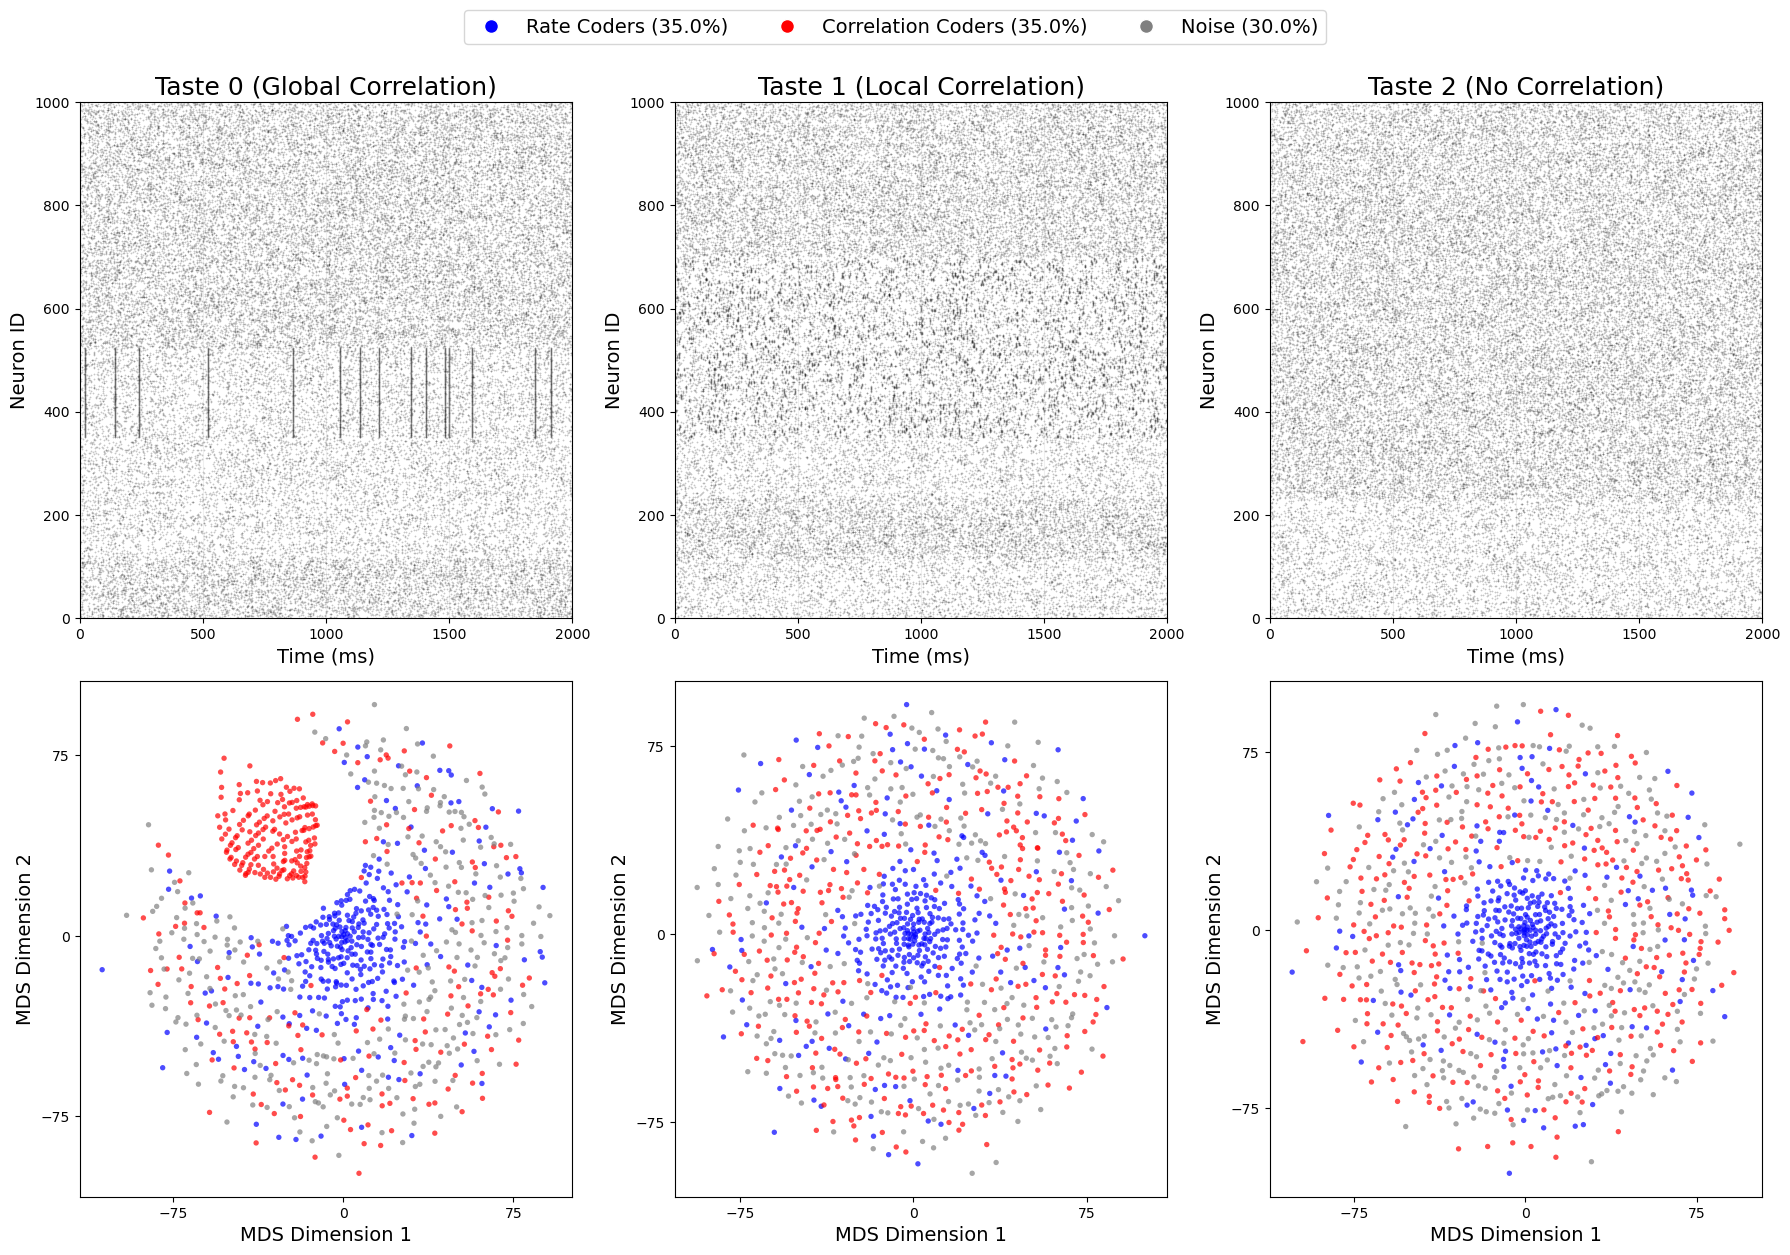

In [31]:
from sklearn.manifold import MDS
from matplotlib.lines import Line2D

def plot_raster_v2(raster, axes):
    """
    Improved raster plot for 1000 neurons that ensures visibility.
    """
    neuron_ids, spike_tim = np.where(raster == 1)
    
    # Increase marker size (s) and linewidth (lw) for better visibility
    # Use alpha=0.8 to ensure pixels actually render on high-res screens
    axes.scatter(spike_tim, neuron_ids, 
                 s=1,              # Increased from 0.1
                 c='black', 
                 marker='o', 
                 alpha=0.2,        # Increased from 0.4
                 linewidths=0.2)   # Added to give the 'pipe' some thickness
    
    axes.set_xlabel("Time (ms)",fontsize = 14)
    axes.set_ylabel("Neuron ID",fontsize = 14)
    axes.set_ylim(0, raster.shape[0])
    axes.set_xlim(0, raster.shape[1])
    axes.grid(True, axis='x', alpha=0.2)

def raster_MDS_plots(rate_pct, corr_pct, n_neurons=1000,random_state = 42):
    n_rate = int(n_neurons * rate_pct)
    n_corr = int(n_neurons * corr_pct)
    n_noise = n_neurons - n_rate - n_corr 
    noise_pct = n_noise / n_neurons

    print(f"Total Neurons: {n_neurons}")
    print(f" - Rate Coders (Blue): {n_rate} ({rate_pct*100:.1f}%)")
    print(f" - Correlation Coders (Red):  {n_corr} ({corr_pct*100:.1f}%)")
    print(f" - Noise (Gray):       {n_noise} ({noise_pct*100:.1f}%)\n")

    #  Generate Dataset
    X, y = generate_hybrid_dataset(rate_percent=rate_pct, corr_percent=corr_pct, n_neurons=n_neurons,random_state=random_state)
    
    # Indices for our representatives
    indices = [1, 31, 62]  # Taste 0, Taste 1, Taste 2
    titles = ['Taste 0 (Global Correlation)', 'Taste 1 (Local Correlation)', 'Taste 2 (No Correlation)']

    colors = (['blue'] * n_rate) + (['red'] * n_corr) + (['gray'] * n_noise)

    # Initialize MDS (of Victor-Purpura distance matrix. Visualizes the metric space structure of the raster with VP distance.)
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, n_jobs=-1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    for col, idx in enumerate(indices):
        raster = X[idx]
        
        ax_raster = axes[0, col]
        plot_raster_v2(raster, axes=ax_raster)
        ax_raster.set_title(f'{titles[col]}', fontsize=18)
        ax_raster.set_xticks([0, 500, 1000, 1500, 2000])
        ax_raster.set_xticklabels([str(t) for t in [0, 500, 1000, 1500, 2000]])

        ax_mds = axes[1, col]
        
        print(f"Calculating VP matrix and MDS for {titles[col]}...")
        vp_dm = VP_trivial(raster)
        embedding = mds.fit_transform(vp_dm)
        
        ax_mds.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=15, alpha=0.7, edgecolors='none')
        
        ax_mds.set_title(f'', fontsize=18)
        ax_mds.set_xlabel('MDS Dimension 1',fontsize = 14)
        ax_mds.set_ylabel('MDS Dimension 2',fontsize = 14)
        ax_mds.set_xticks([-75,0,75])
        ax_mds.set_yticks([-75,0,75])
        # ax_mds.grid(True, linestyle='--', alpha=0.5)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'Rate Coders ({rate_pct*100:.1f}%)', markerfacecolor='blue', markersize=10),
        Line2D([0], [0], marker='o', color='w', label=f'Correlation Coders ({corr_pct*100:.1f}%)', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label=f'Noise ({noise_pct*100:.1f}%)', markerfacecolor='gray', markersize=10)
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=14, bbox_to_anchor=(0.5, 1.05))

    plt.tight_layout()
    



# Example plot
raster_MDS_plots(rate_pct=0.35, corr_pct=0.35, n_neurons=1000,random_state = 42)
plt.savefig('Hybrid-coding-example-figure.pdf',bbox_inches = 'tight')


# TDA and SVM on Hybrid Datasets

In [49]:
import time
rate_pct_list = [0.0, # 0 %
                 0.01, # 1%
                 0.02, # 2%
                 0.03, # 3%
                 0.04, # 4%
                 0.05, # 5%
                 0.1, # 10%
                 0.2, # 20%
                 0.3, # 30%
                 0.4, # 40%
                 0.5, # 50%
                 0.6, # 60%
                 ]



results = []
n_neurons = 1000

for rate_pct in tqdm(rate_pct_list, desc="Running rate_pct experiments"):
    corr_pct = 0.70 - rate_pct
    print(f"\nGenerating mix -> Rate: {rate_pct*100:.1f}%, Correlation: {corr_pct*100:.1f}%")

    # Generate the data
    X, y = generate_hybrid_dataset(rate_percent=rate_pct, corr_percent=corr_pct, n_neurons = 1000, random_state = 42)

    # TDA Original
    print("  Running TDA...")
    tda_start = time.perf_counter()
    tda_acc = tda_rhv(X, y)
    tda_runtime = time.perf_counter() - tda_start
    print(f"  TDA done | Acc: {tda_acc:.4f} | Time: {tda_runtime:.2f} s")

    # SVM Pure Rate
    print("  Running SVM...")
    svm_start = time.perf_counter()
    svm_acc, _, _ = svm_smoothed_rasters(X, y)
    svm_runtime = time.perf_counter() - svm_start
    print(f"  SVM done | Acc: {svm_acc:.4f} | Time: {svm_runtime:.2f} s")

    # Save the results
    results.append({
        'Rate_Percent': rate_pct,
        'Corr_Percent': corr_pct,
        'TDA_Acc': tda_acc,
        'TDA_Runtime_Sec': tda_runtime,
        'SVM_Acc': svm_acc,
        'SVM_Runtime_Sec': svm_runtime
    })
    

Running rate_pct experiments:   0%|          | 0/12 [00:00<?, ?it/s]


Generating mix -> Rate: 0.0%, Correlation: 70.0%
  Running TDA...


Building BDM: 100%|██████████| 90/90 [00:05<00:00, 16.72it/s]


  TDA done | Acc: 1.0000 | Time: 624.04 s
  Running SVM...


Running rate_pct experiments:   8%|▊         | 1/12 [12:30<2:17:35, 750.53s/it]

...

  SVM done | Acc: 1.0000 | Time: 114.77 s

Generating mix -> Rate: 60.0%, Correlation: 10.0%
  Running TDA...


Building BDM: 100%|██████████| 90/90 [00:14<00:00,  6.21it/s]


  TDA done | Acc: 0.4000 | Time: 706.65 s
  Running SVM...


Running rate_pct experiments: 100%|██████████| 12/12 [3:25:46<00:00, 1028.84s/it]

  SVM done | Acc: 1.0000 | Time: 266.37 s


In [5]:
import pandas as pd
# save results
# df_results = pd.DataFrame(results)

# df_results.to_csv('hybrid_experiment_results.csv', index=False)

df_results = pd.read_csv('hybrid_experiment_results.csv')
df_results.head()

,Rate_Percent,Corr_Percent,TDA_Acc,TDA_Runtime_Sec,SVM_Acc,SVM_Runtime_Sec
0,0.00,0.70,1.000000,624.041495,0.285185,124.725696
1,0.01,0.69,0.988889,632.707229,0.574074,111.626549
2,0.02,0.68,1.000000,638.054790,0.825926,127.074838
3,0.03,0.67,0.988889,636.957672,0.918519,124.229747
4,0.04,0.66,0.983333,632.795535,0.964815,116.558600


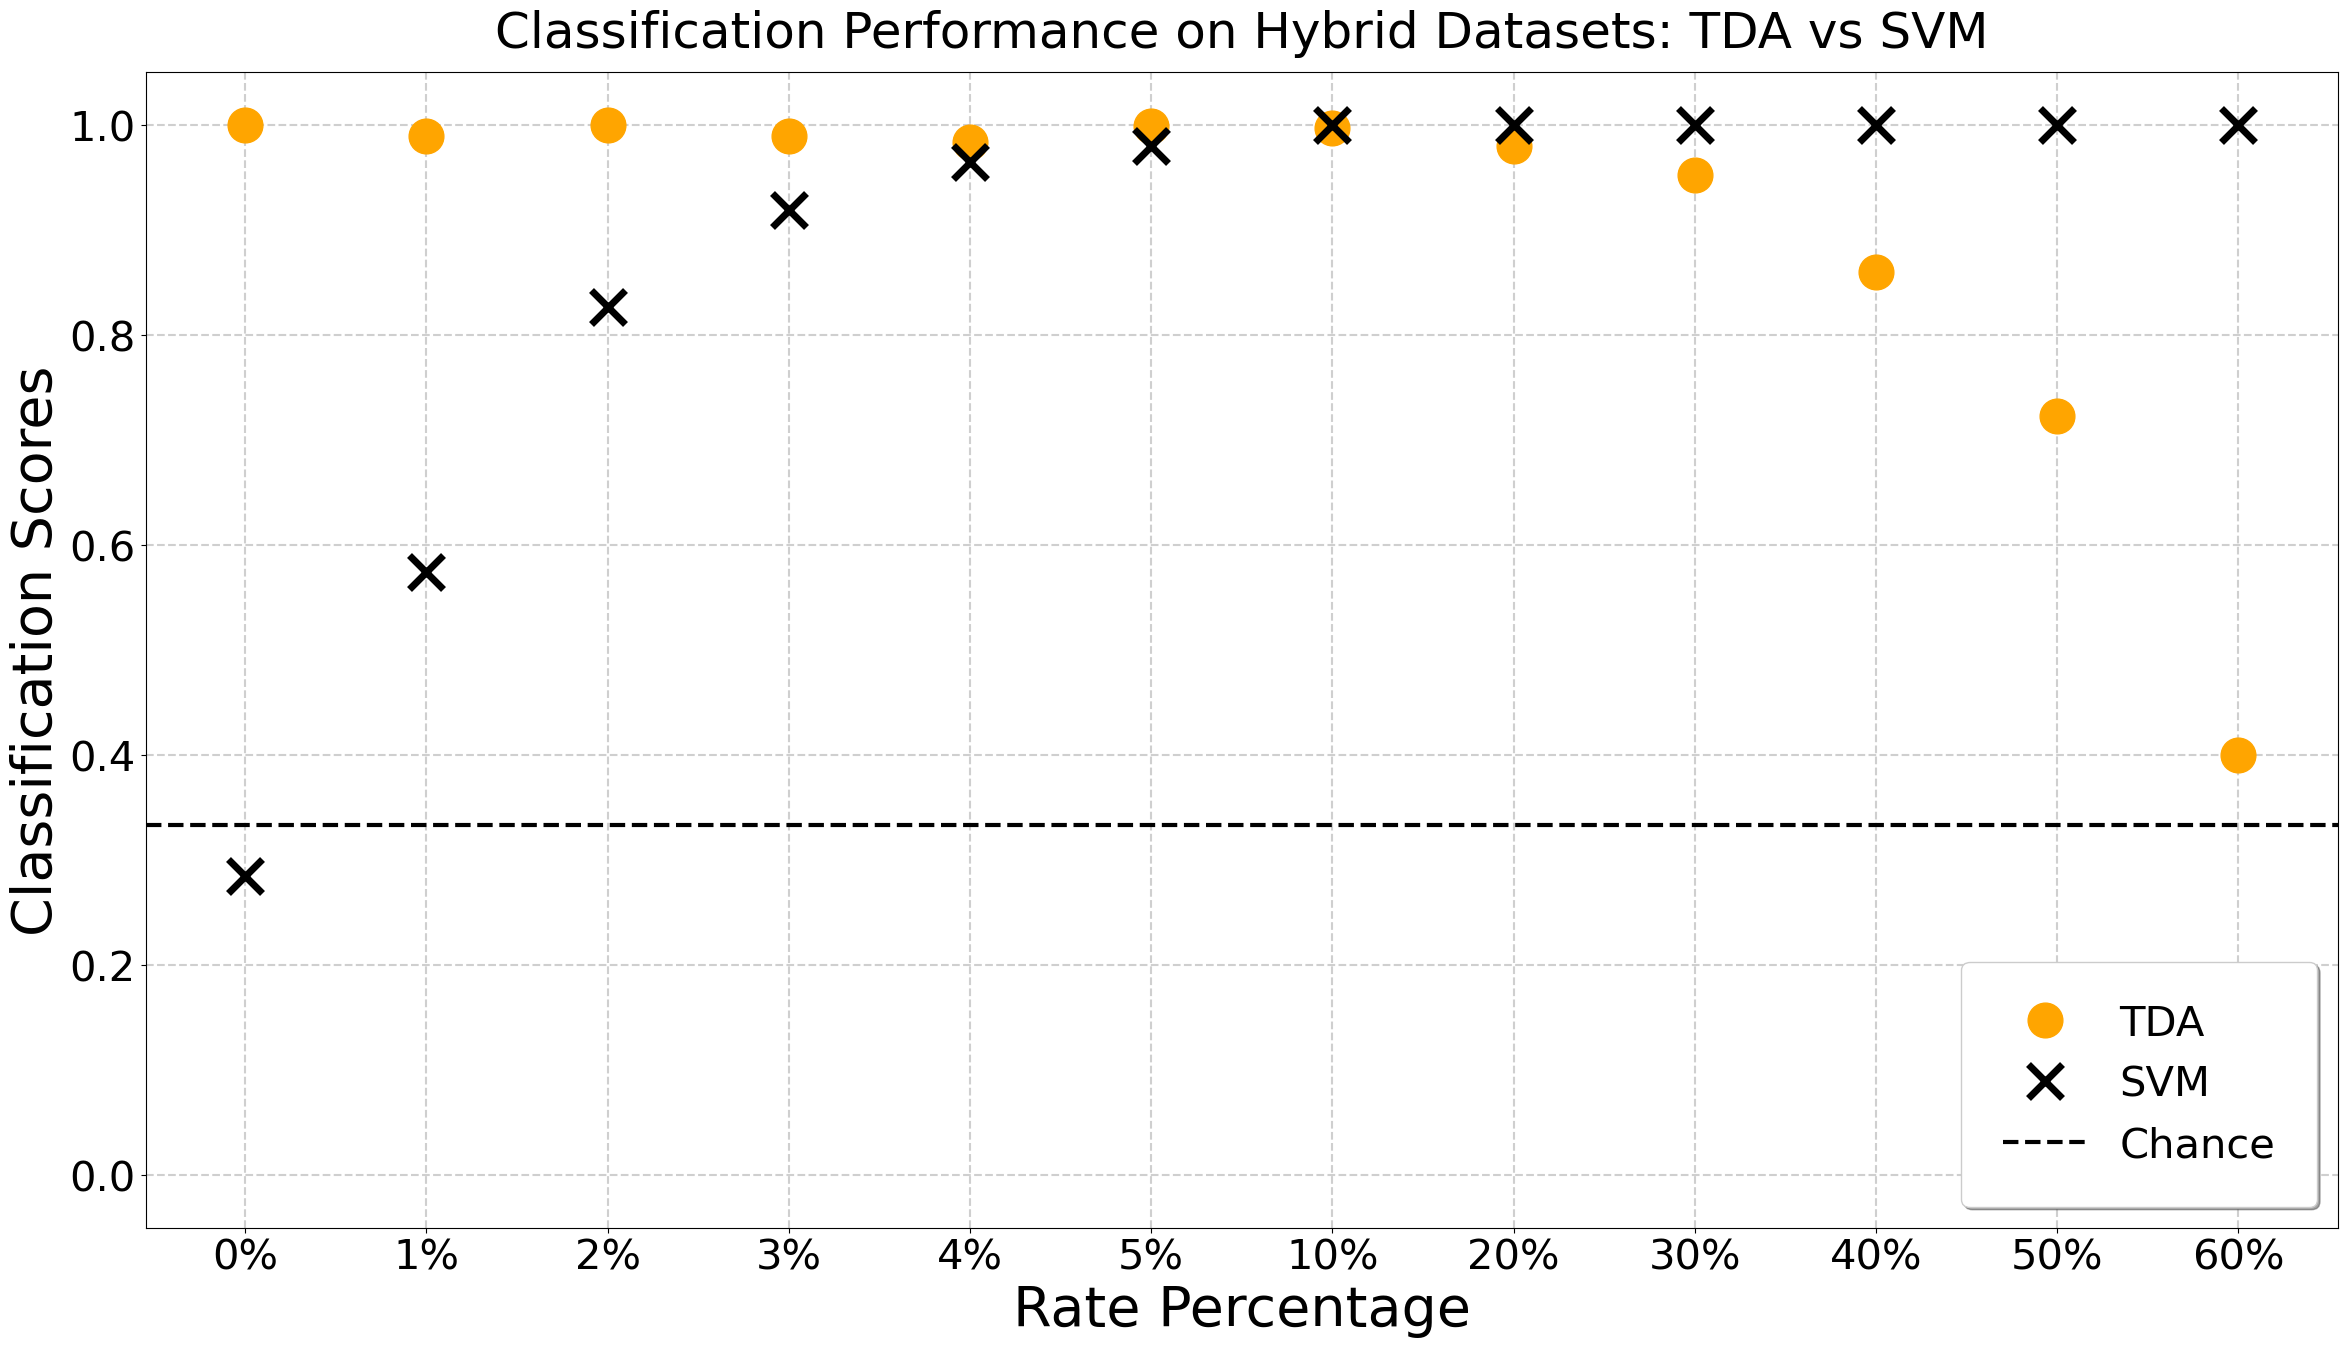

In [24]:

df_results = df_results.sort_values(by='Rate_Percent').reset_index(drop=True)

import matplotlib.pyplot as plt
plt.rcParams.update({
    # --- Global Font Properties ---
    'font.family': 'sans-serif',    # Base font family (e.g., 'sans-serif', 'serif', 'monospace')
    'font.size': 24,                # Global default font size (affects everything not explicitly set below)
    
    # --- Figure & Subplot Titles ---
    'figure.titlesize': 36,         # Size of the overall figure title (plt.suptitle)
    'figure.titleweight': 'bold',   # Font weight of the overall figure title
    'axes.titlesize': 36,           # Size of individual subplot titles (ax.set_title)
    'axes.titleweight': 'normal',   # Font weight of subplot titles
    
    # --- Axis Labels (X and Y titles) ---
    'axes.labelsize': 40,           # Size of x and y axis labels (ax.set_xlabel, ax.set_ylabel)
    'axes.labelweight': 'normal',     # Font weight of axis labels
    
    # --- Tick Labels (The numbers/text on the axes) ---
    'xtick.labelsize': 30,          # Font size of x-axis tick numbers
    'ytick.labelsize': 30,          # Font size of y-axis tick numbers
    
    # --- Legend ---
    'legend.fontsize': 30,          # Font size of the text inside the legend
    'legend.title_fontsize': 30,    # Font size of the legend's title

    # --- pad---
    'axes.titlepad': 18
})

plt.figure(figsize=(24, 14)) # Large canvas

# Plot TDA (Orange Dots)
plt.plot(df_results.index, df_results['TDA_Acc'], 'o', 
         color='orange', label='TDA', markersize=25)

# Plot SVM (Black Plus Signs)
plt.plot(df_results.index, df_results['SVM_Acc'], 'x', 
         color='black', label='SVM', markersize=25, mew=5)

# Random Guessing line
plt.axhline(y=1/3, color='black', linestyle='--',lw = 3, label = 'Chance')

# Create custom x-tick labels: (Rate %, Sync %)
x_labels = [f"{int(round(r*100, 1))}%" for r in df_results['Rate_Percent']]

plt.xticks(range(len(df_results)), x_labels, rotation=0)

# Formatting with large labels
plt.xlabel("Rate Percentage")
plt.ylabel("Classification Scores")
plt.title("Classification Performance on Hybrid Datasets: TDA vs SVM")
plt.ylim(-0.05, 1.05)

# Enhanced Legend
plt.legend(loc='lower right', frameon=True, shadow=True, borderpad=1)
plt.grid(True, linestyle='--', alpha=0.6, linewidth=1.5)

plt.tight_layout()
plt.savefig('hybrid_datasets_tda_vs_svm.pdf')
plt.show()

Total Neurons: 1000
 - Rate Coders (Blue): 350 (35.0%)
 - Correlation Coders (Red):  350 (35.0%)
 - Noise (Gray):       300 (30.0%)

Calculating VP matrix and MDS for Stim-0 (Global Correlation)...


/Users/cgty/anaconda3/envs/spike_train_tda/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Calculating VP matrix and MDS for Stim-1 (Local Correlation)...


/Users/cgty/anaconda3/envs/spike_train_tda/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Calculating VP matrix and MDS for Stim-2 (No Correlation)...


/Users/cgty/anaconda3/envs/spike_train_tda/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


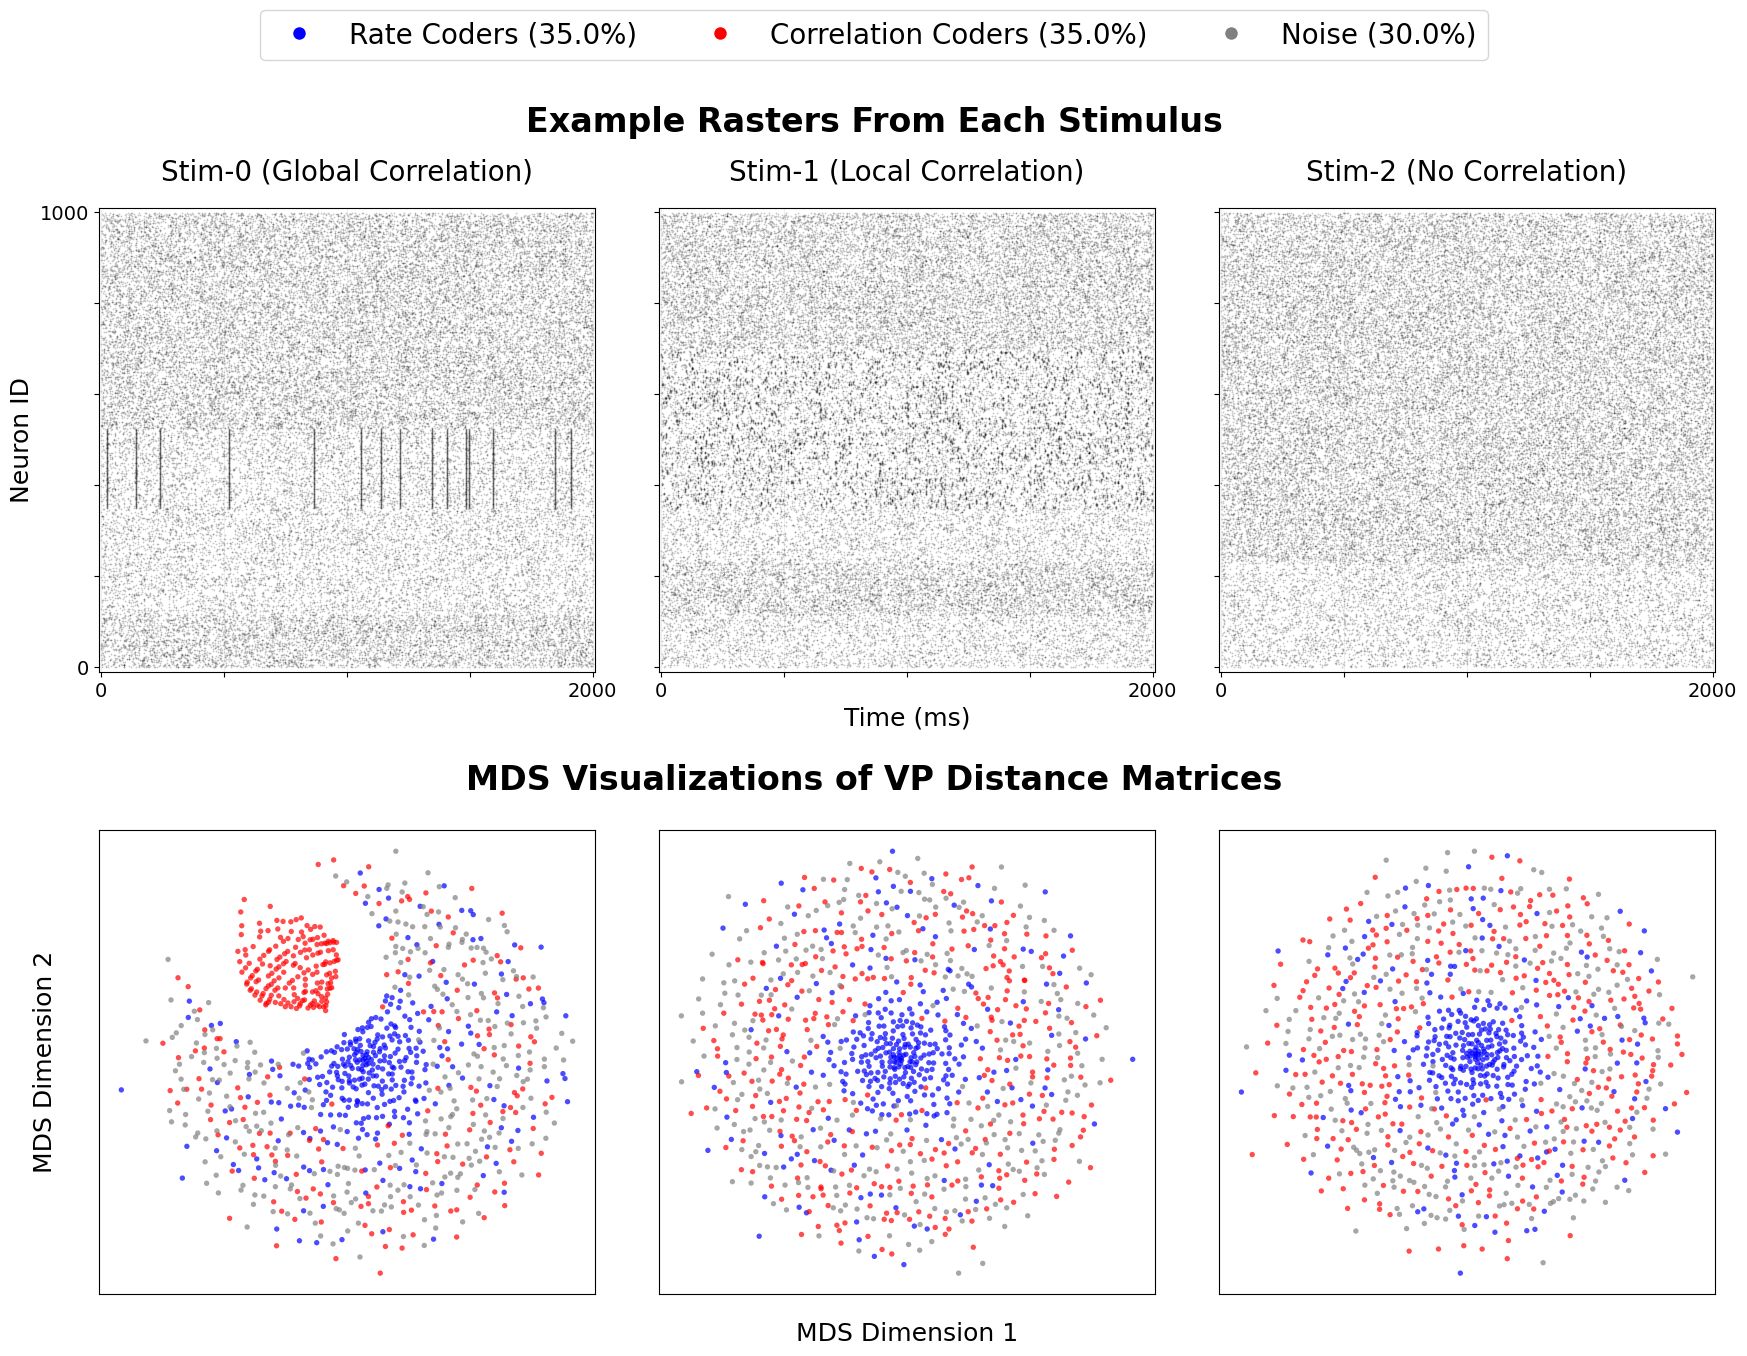

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import MDS

# --- Universal Font Controls ---
plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 20,
    'axes.titlepad': 20 
})

def plot_raster_v2(raster, axes):
    """
    Improved raster plot for 1000 neurons that ensures visibility.
    """
    neuron_ids, spike_tim = np.where(raster == 1)
    
    axes.scatter(spike_tim, neuron_ids, 
                 s=1,              
                 c='black', 
                 marker='o', 
                 alpha=0.2,        
                 linewidths=0.2)   
    
    # REMOVED: set_xlabel and set_ylabel from here so we can control them explicitly in the loop
    axes.set_ylim(0, raster.shape[0])
    axes.set_xlim(0, raster.shape[1])
    axes.grid(True, axis='x', alpha=0.2)

def raster_MDS_plots(rate_pct, corr_pct, n_neurons=1000, random_state=42):
    n_rate = int(n_neurons * rate_pct)
    n_corr = int(n_neurons * corr_pct)
    n_noise = n_neurons - n_rate - n_corr 
    noise_pct = n_noise / n_neurons

    print(f"Total Neurons: {n_neurons}")
    print(f" - Rate Coders (Blue): {n_rate} ({rate_pct*100:.1f}%)")
    print(f" - Correlation Coders (Red):  {n_corr} ({corr_pct*100:.1f}%)")
    print(f" - Noise (Gray):       {n_noise} ({noise_pct*100:.1f}%)\n")

    # Generate Dataset
    X, y = generate_hybrid_dataset(rate_percent=rate_pct, corr_percent=corr_pct, n_neurons=n_neurons, random_state=random_state)
    
    # Indices for our representatives
    indices = [1, 31, 62]  # Stim-0, Stim-1, Stim-2
    titles = ['Stim-0 (Global Correlation)', 'Stim-1 (Local Correlation)', 'Stim-2 (No Correlation)']

    colors = (['blue'] * n_rate) + (['red'] * n_corr) + (['gray'] * n_noise)

    # Initialize MDS 
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, n_jobs=-1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 14))

    for col, idx in enumerate(indices):
        raster = X[idx]
        
        # -----------------------------------------
        # ROW 1: RASTER PLOTS
        # -----------------------------------------
        ax_raster = axes[0, col]
        plot_raster_v2(raster, axes=ax_raster)
        
        ax_raster.set_title(titles[col])
        ax_raster.set_xticks([0, 500, 1000, 1500, 2000])
        ax_raster.set_xticklabels(['0', '', '', '', '2000'])
        ax_raster.set_xlim(-10, 2010)
        ax_raster.set_ylim(-10, n_neurons + 10)
        
        # Center the X-axis label for the top row
        if col == 1:
            ax_raster.set_xlabel("Time (ms)")
        else:
            ax_raster.set_xlabel("")
        
        # Share Y-Axis for Rasters (Only label the first column)
        y_ticks = np.linspace(0, n_neurons, 6, dtype=int)
        if col == 0:
            ax_raster.set_ylabel("Neuron ID", fontweight='normal')
            ax_raster.set_yticks(y_ticks)
            ax_raster.set_yticklabels(['0','','','','',str(n_neurons)])
        else:
            ax_raster.set_ylabel("")
            plt.setp(ax_raster.get_yticklabels(), visible=False)


        # -----------------------------------------
        # ROW 2: MDS PLOTS
        # -----------------------------------------
        ax_mds = axes[1, col]
        
        print(f"Calculating VP matrix and MDS for {titles[col]}...")
        vp_dm = VP_trivial(raster)
        embedding = mds.fit_transform(vp_dm)
        
        ax_mds.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=15, alpha=0.7, edgecolors='none')
        
        ax_mds.set_title("") # No titles needed for the bottom row
        ax_mds.set_xticks([])
        ax_mds.set_yticks([])
        
        # Center the X-axis label for the bottom row
        if col == 1:
            ax_mds.set_xlabel('MDS Dimension 1',labelpad = 20)
        else:
            ax_mds.set_xlabel("")
        
        # Share Y-Axis for MDS (Only label the first column)
        if col == 0:
            ax_mds.set_ylabel('MDS Dimension 2', fontweight='normal',labelpad = 30)
        else:
            ax_mds.set_ylabel("")
            plt.setp(ax_mds.get_yticklabels(), visible=False)


    # -----------------------------------------
    # ROW TITLES, LEGEND & CLEANUP
    # -----------------------------------------
    
    # Add High-Level Row Titles using figure coordinates
    fig.text(0.5, 0.90, "Example Rasters From Each Stimulus", ha='center', va='center', fontweight='bold')
    fig.text(0.5, 0.43, "MDS Visualizations of VP Distance Matrices", ha='center', va='center', fontweight='bold')

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'Rate Coders ({rate_pct*100:.1f}%)', markerfacecolor='blue', markersize=10),
        Line2D([0], [0], marker='o', color='w', label=f'Correlation Coders ({corr_pct*100:.1f}%)', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label=f'Noise ({noise_pct*100:.1f}%)', markerfacecolor='gray', markersize=10)
    ]
    
    # Legend pushed to the very top
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.99))

    # Increased h_pad to 5.0 to make sure the middle row title doesn't crash into the top plots
    # Adjust rect to leave room for the top title and legend
    plt.tight_layout(rect=[0, 0, 1, 0.90], h_pad=3.0) 
    
    plt.savefig('Hybrid-coding-example-figure.pdf', bbox_inches='tight')
    plt.show()

# Example plot
raster_MDS_plots(rate_pct=0.35, corr_pct=0.35, n_neurons=1000, random_state=42)